#### Student Name:Kevin Cao
#### Student ID:A18315089

# PCA with Linear Autoencoder

Instructions: 

* This notebook is an interactive assignment; please read and follow the instructions in each cell. 

* Cells that require your input (in the form of code or written response) will have 'Question #' above.

* After completing the assignment, please submit this notebook as a PDF.


You may need to run the following commands to set up your environment:

`pip install tensorflow`

`pip install keras`

`pip install --upgrade protobuf`

In [13]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.io import wavfile
from numpy.linalg import svd
from scipy.stats.mstats import gmean
from matplotlib import rcParams
import scipy
import os
import sys
import glob
import pickle
from music21 import converter, instrument, note, chord, stream
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Activation, Lambda
from keras.layers import BatchNormalization as BatchNorm
from keras.callbacks import ModelCheckpoint
import tensorflow.compat.v1 as tf
tf.disable_eager_execution()
tf.disable_v2_behavior()

# PCA with a Linear Autoencoder

In this problem, we will practice using basic neural network procedures by running an autoencoder network.
This network is implemented in TensorFlow (essentially Keras with an expanded toolset); the functions we call are nearly identical to those you will see in Keras. 

Let's create a sin+noise signal to use as input to our network:

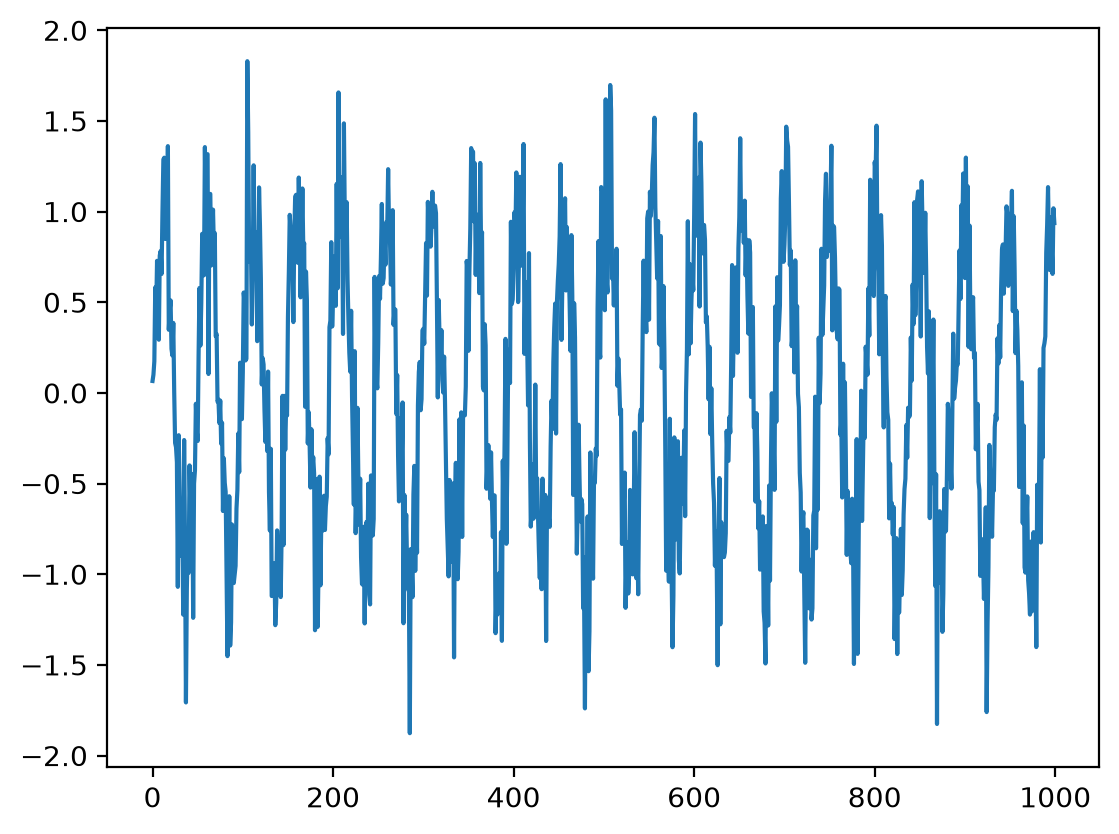

In [14]:
f0 = 203
fs = 10000
T = 3
Ns = fs*T

def buffer(input_data, sample_rate, window_size, hop_size):
    output = np.array([input_data[i:i+window_size] for i in range(0, len(input_data)-window_size, hop_size)])
    return output.T

s = np.sin(2*np.pi*f0*np.arange(Ns)/fs)

n = np.random.randn(Ns)

x = s + 0.3*n 

plt.plot(x[:1000])
wavfile.write('out2.wav', fs, x)
xmat = buffer(x,fs,400,200)

Here we create an AE with 2 hidden layers. 

This neural network is implemented in TensorFlow. 

Please review the code cells below, and answer the questions that follow. 

In [15]:
n_inputs = np.shape(xmat)[0]
n_hidden = 2 

learning_rate = 0.01 

X = tf.compat.v1.placeholder(tf.float32, shape=[None, n_inputs])
W = tf.Variable(tf.truncated_normal(stddev=.1, shape =[n_inputs,n_hidden]))

hidden = tf.matmul(X,W)
outputs = tf.matmul(hidden,tf.transpose(W))

reconstruction_loss = tf.reduce_mean(tf.square(outputs - X))

optimizer = tf.train.AdamOptimizer(learning_rate)
training_op = optimizer.minimize(reconstruction_loss)

init = tf.global_variables_initializer()

ERROR:tensorflow:An interactive session is already active. This can cause out-of-memory errors or some other unexpected errors (due to the unpredictable timing of garbage collection) in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s). Please use `tf.Session()` if you intend to productionize.


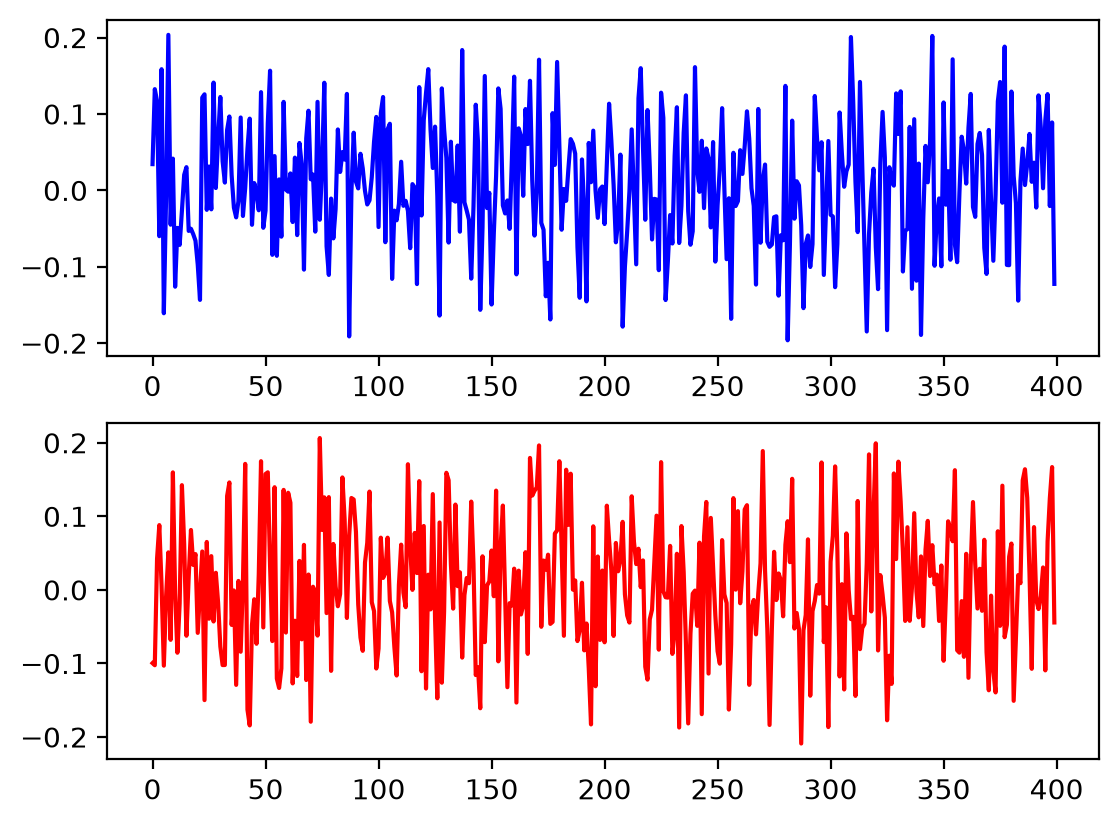

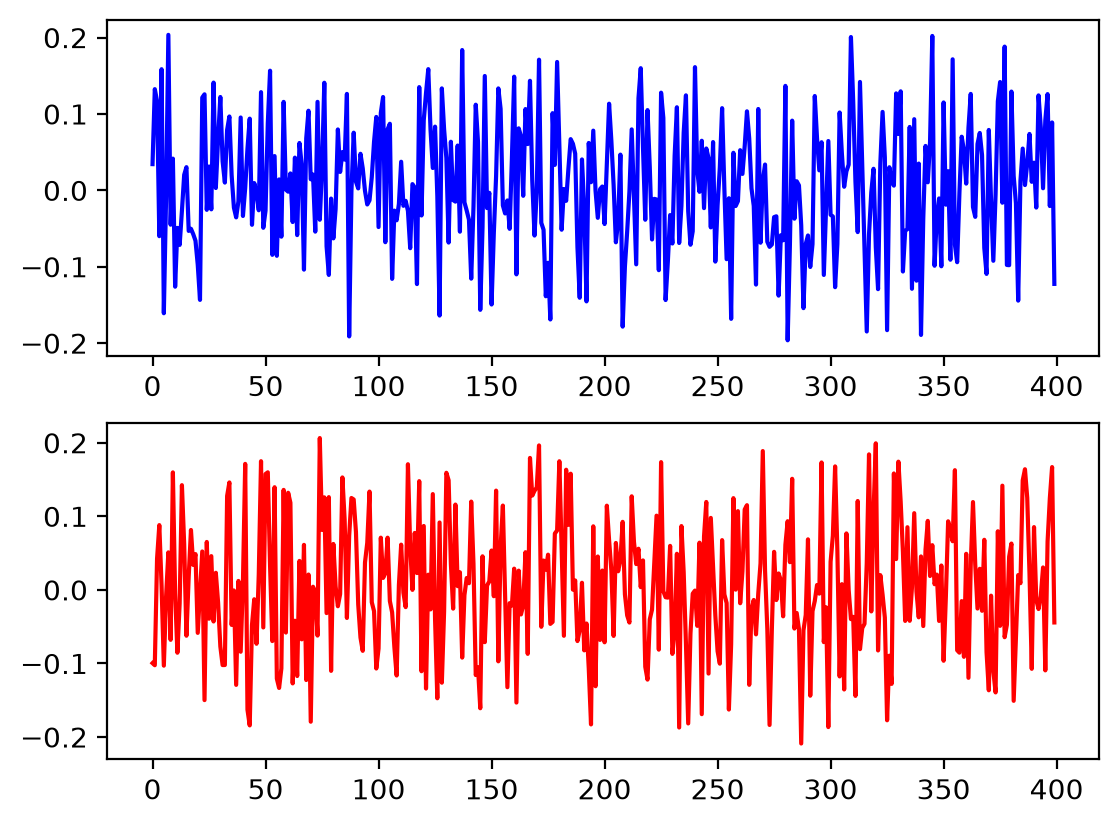

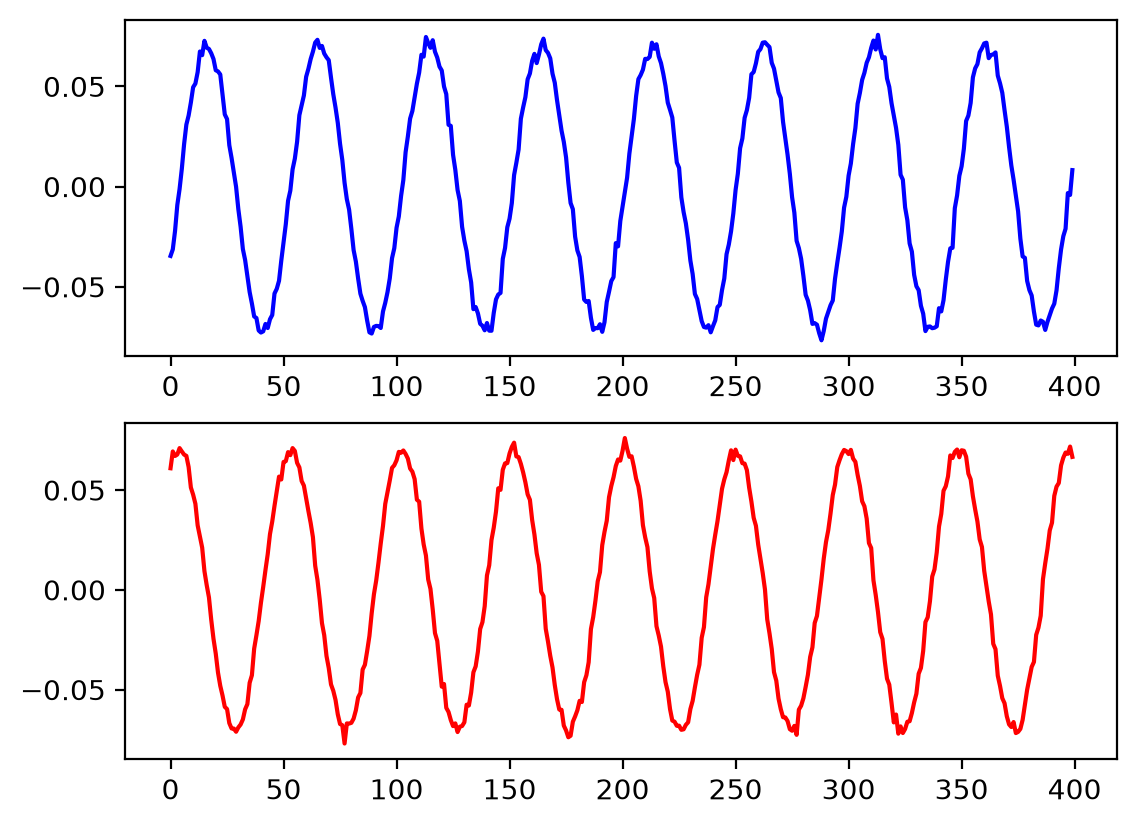

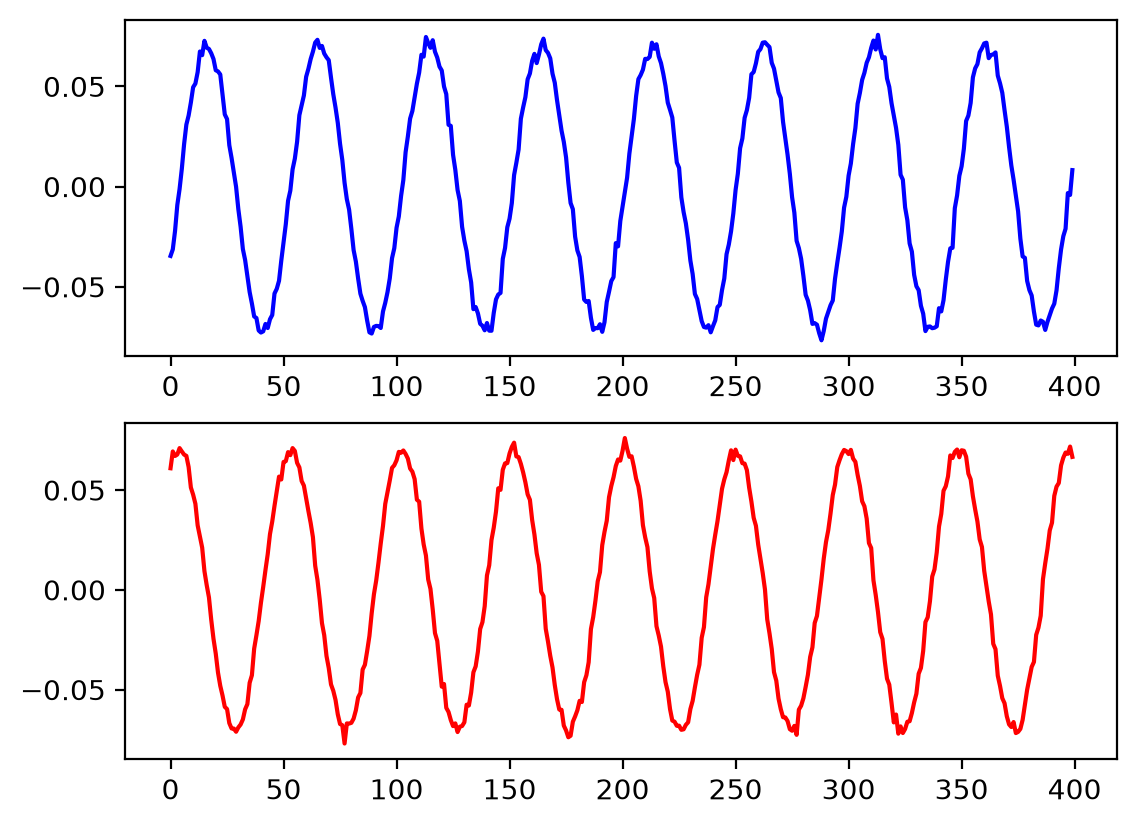

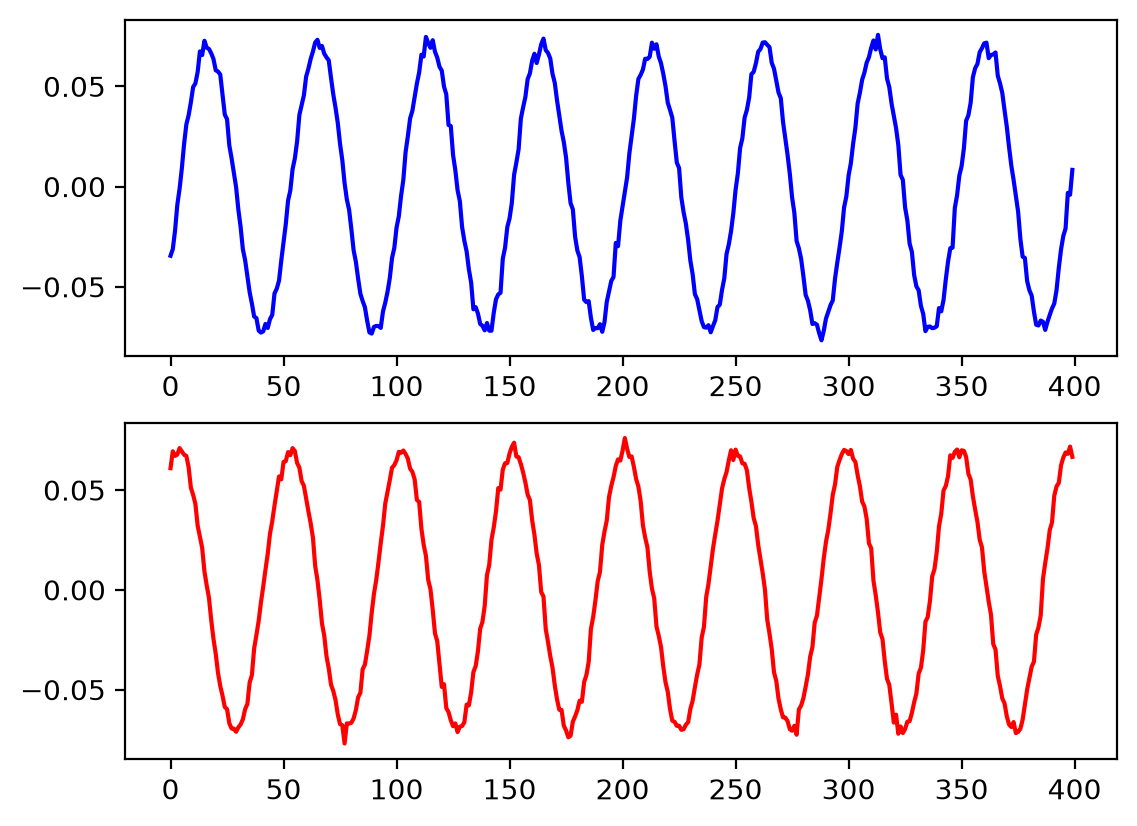

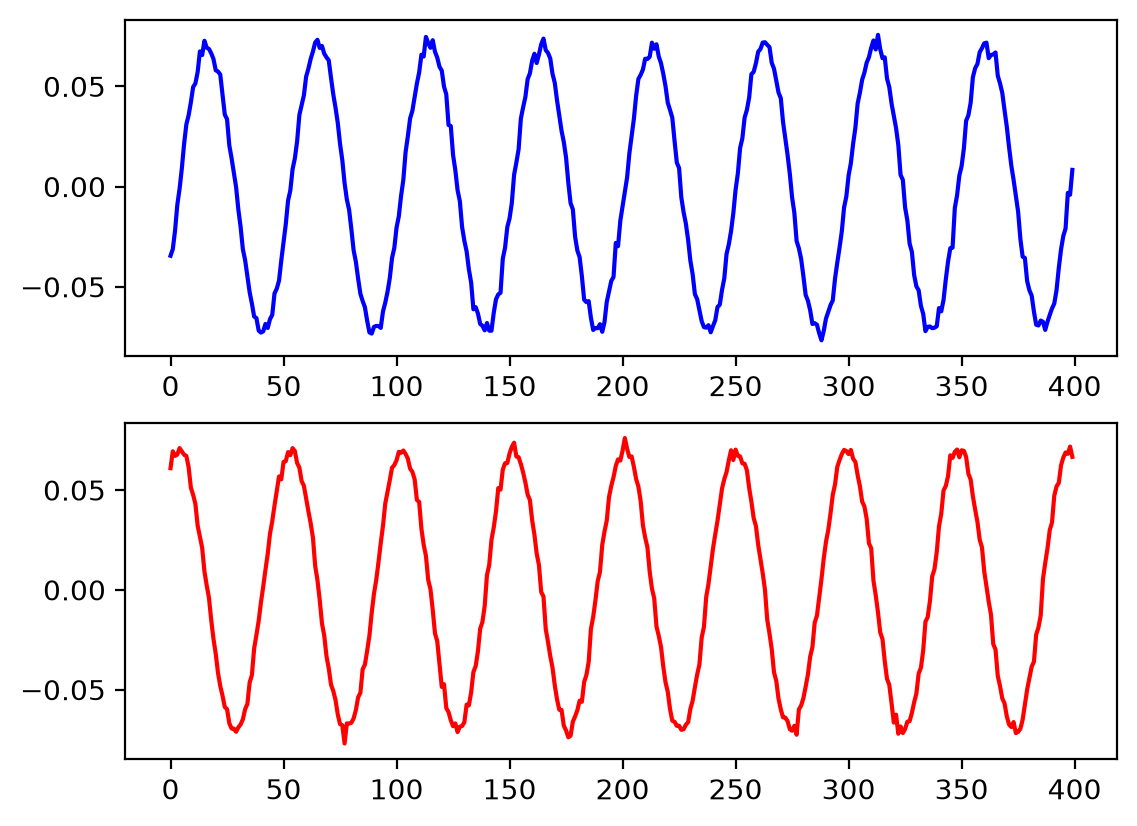

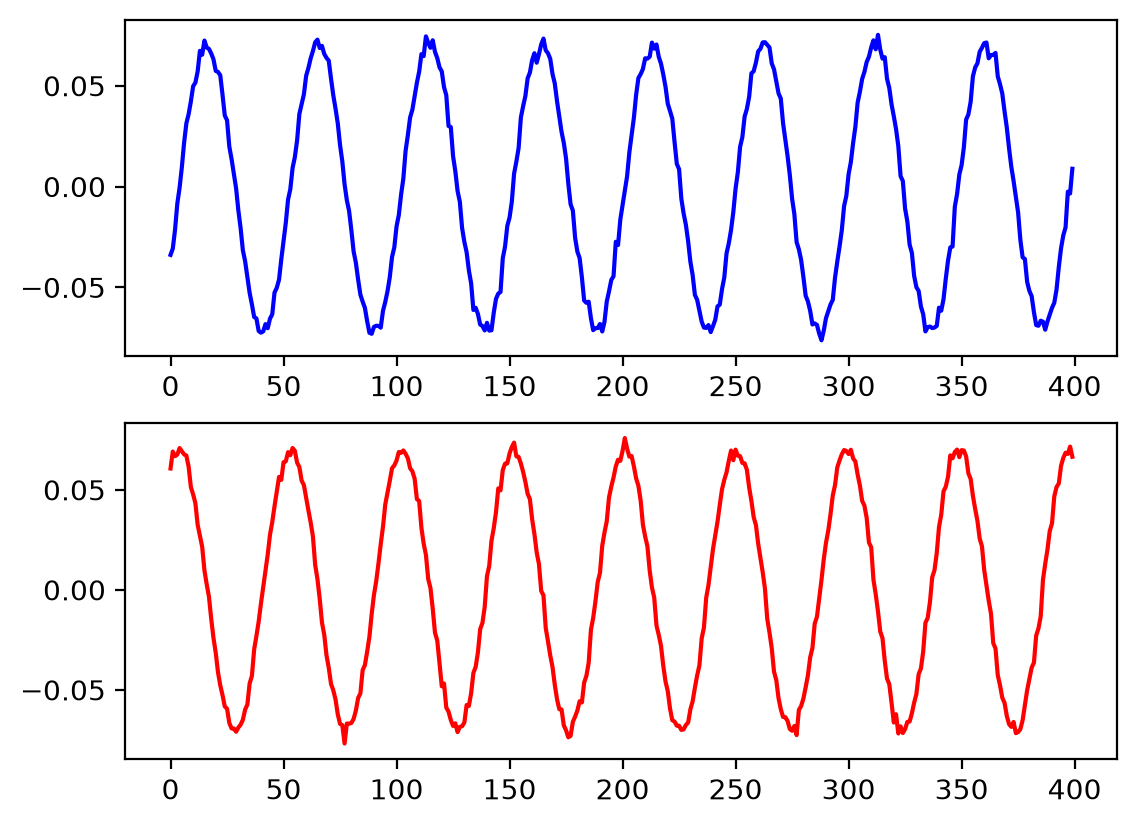

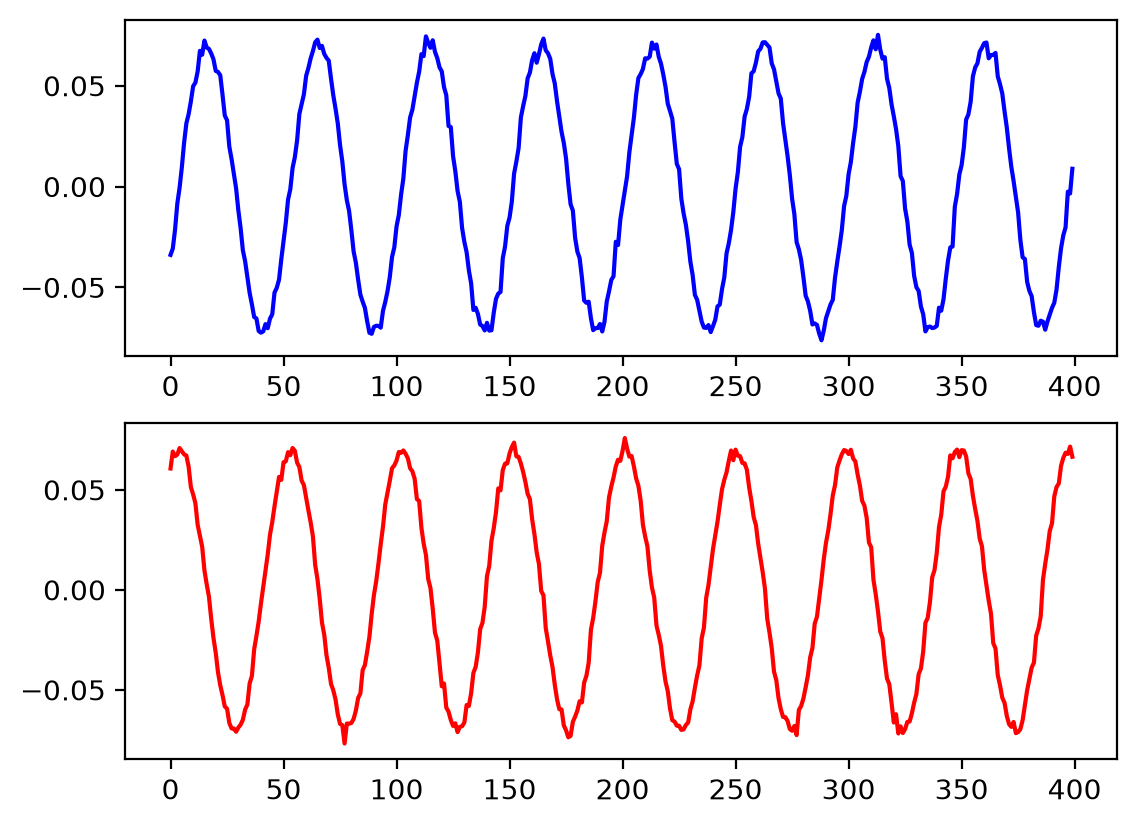

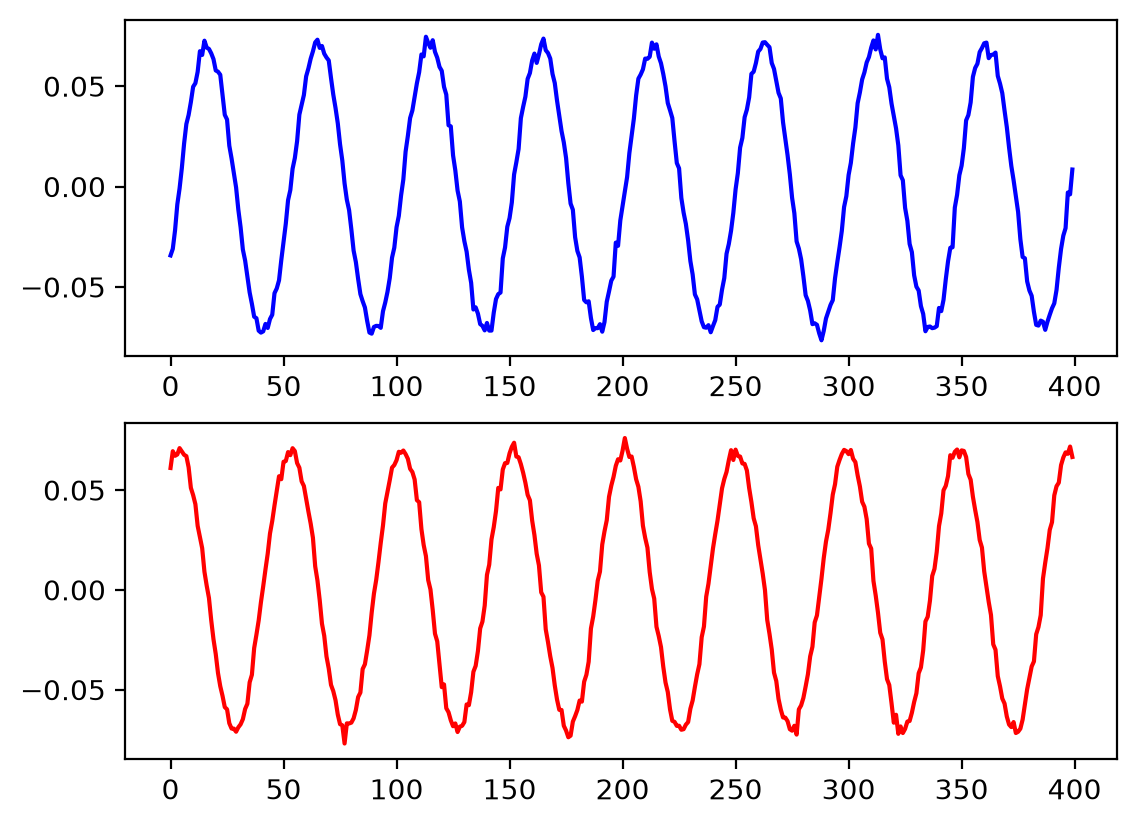

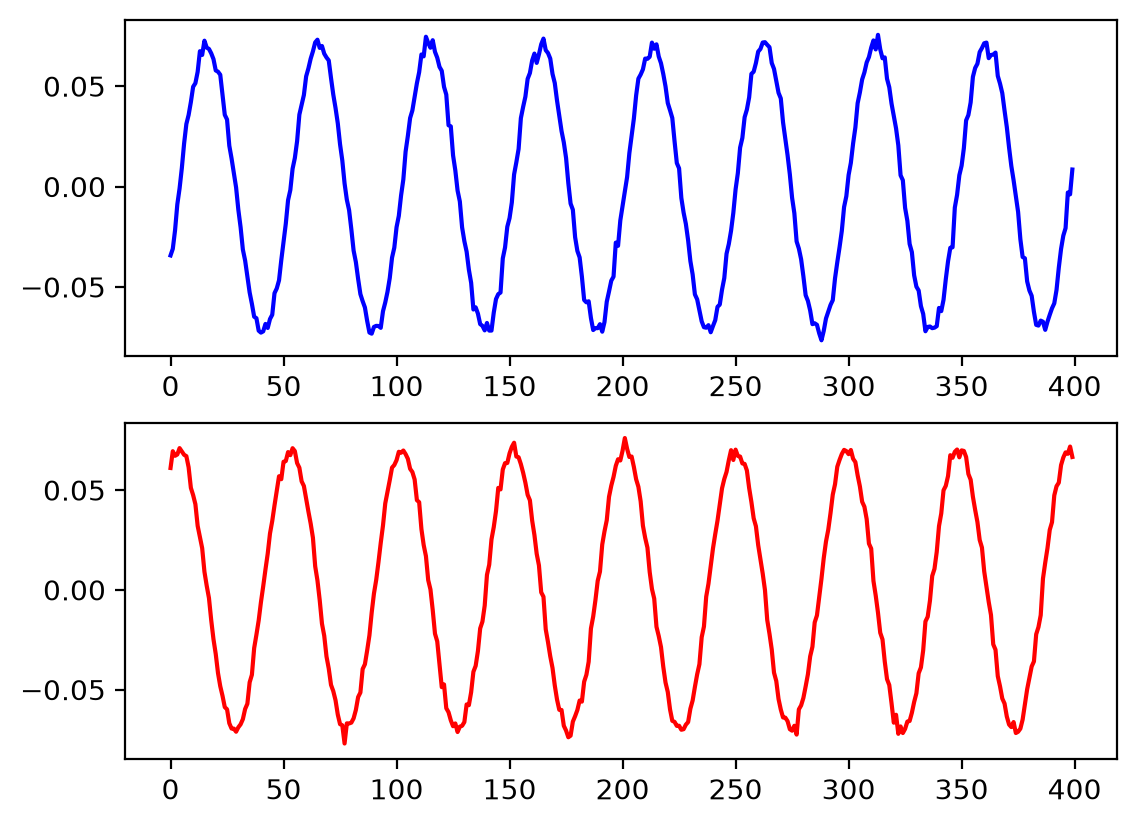

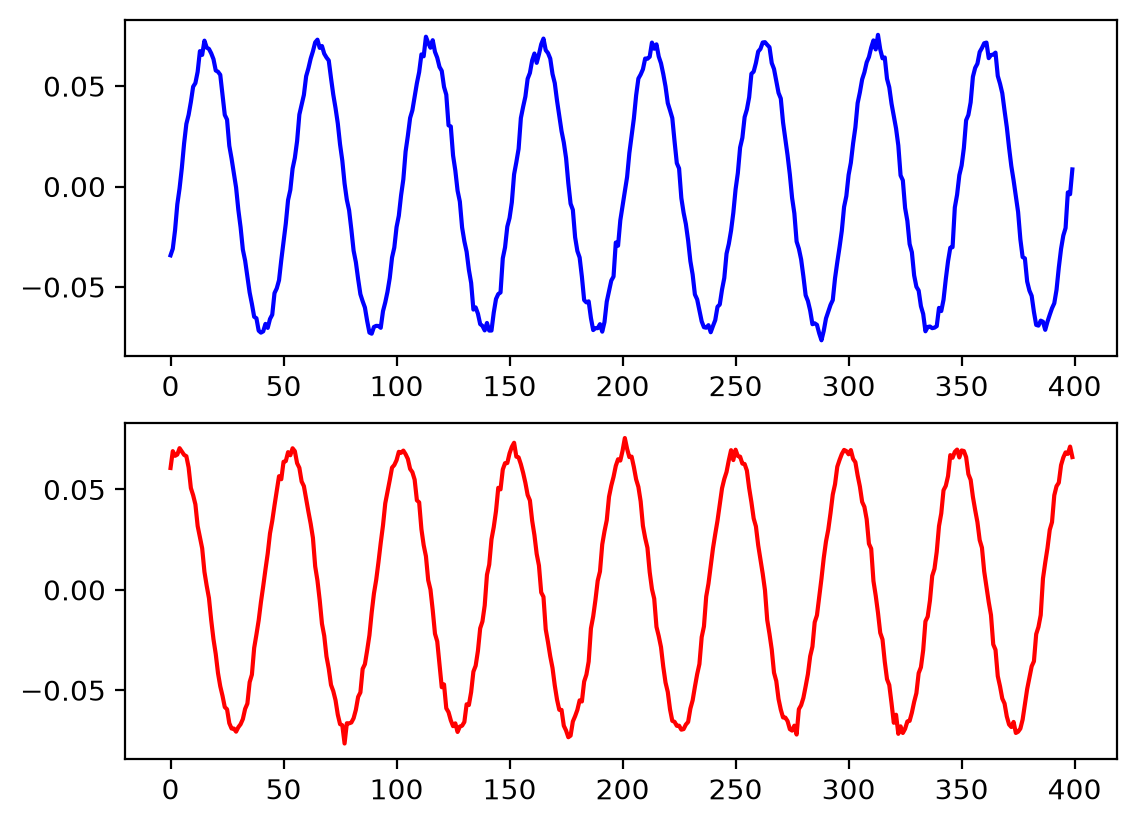

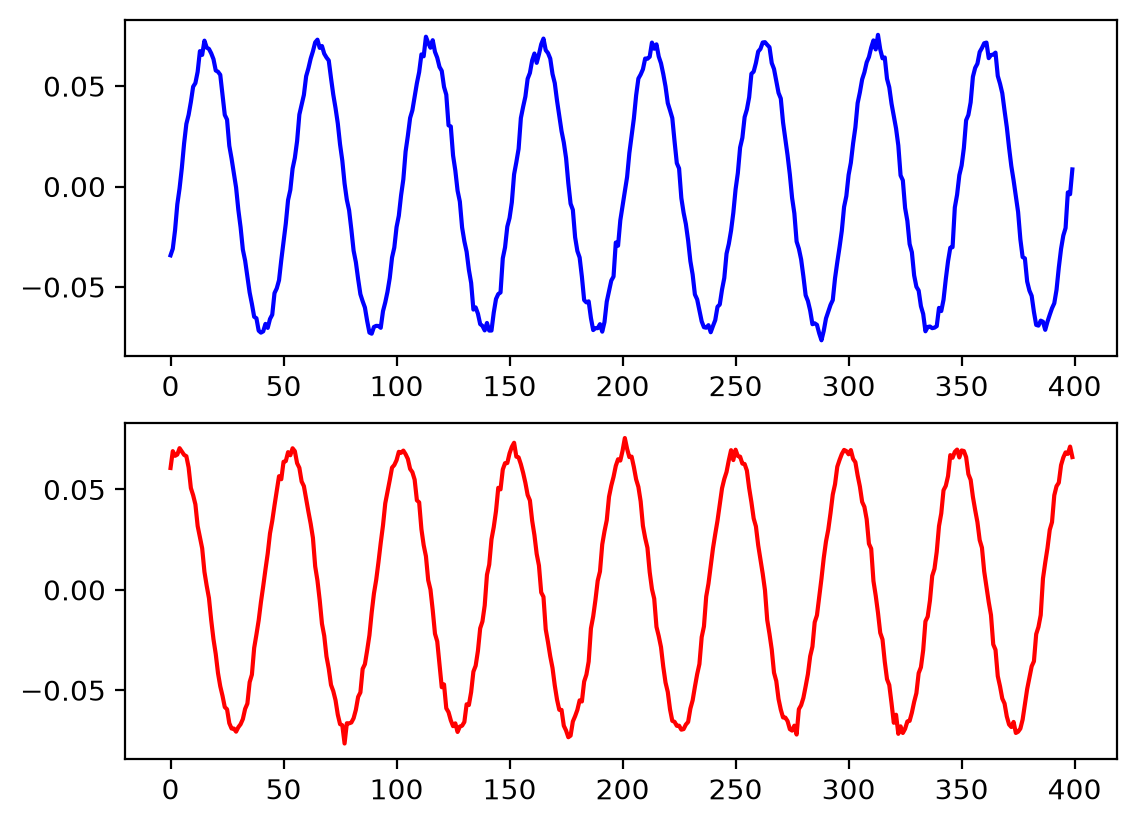

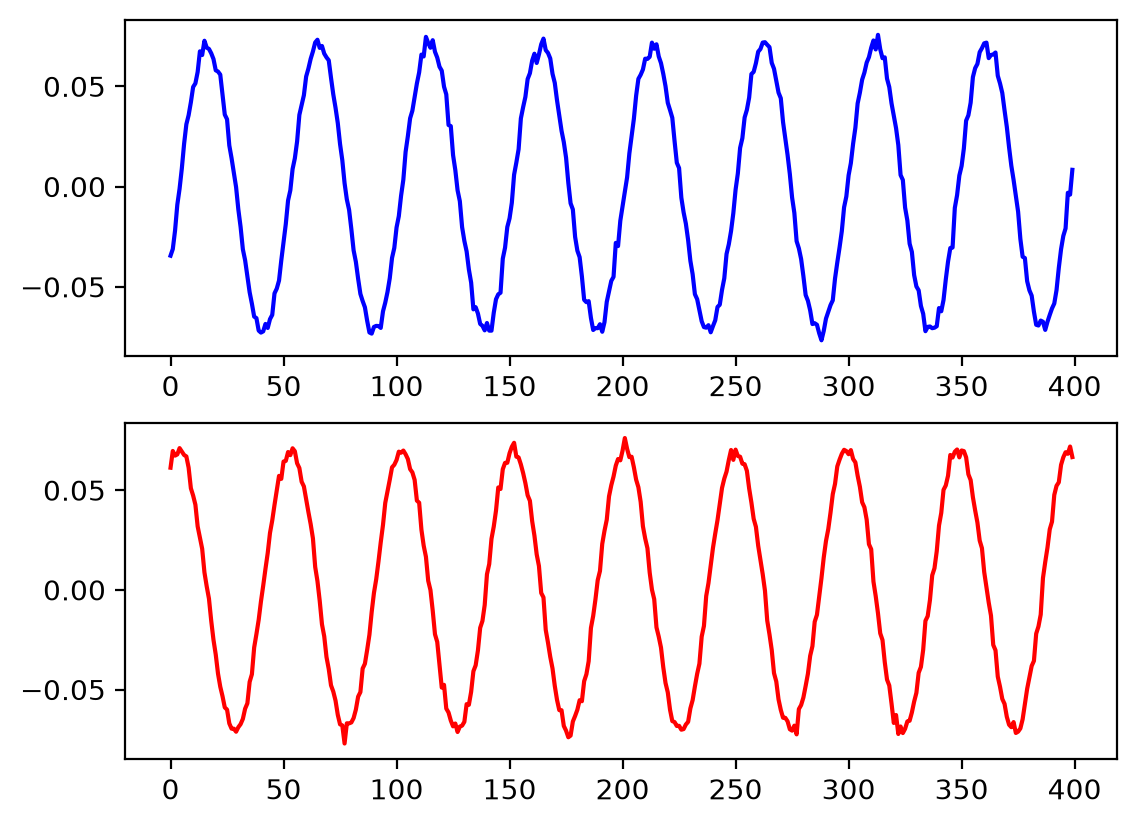

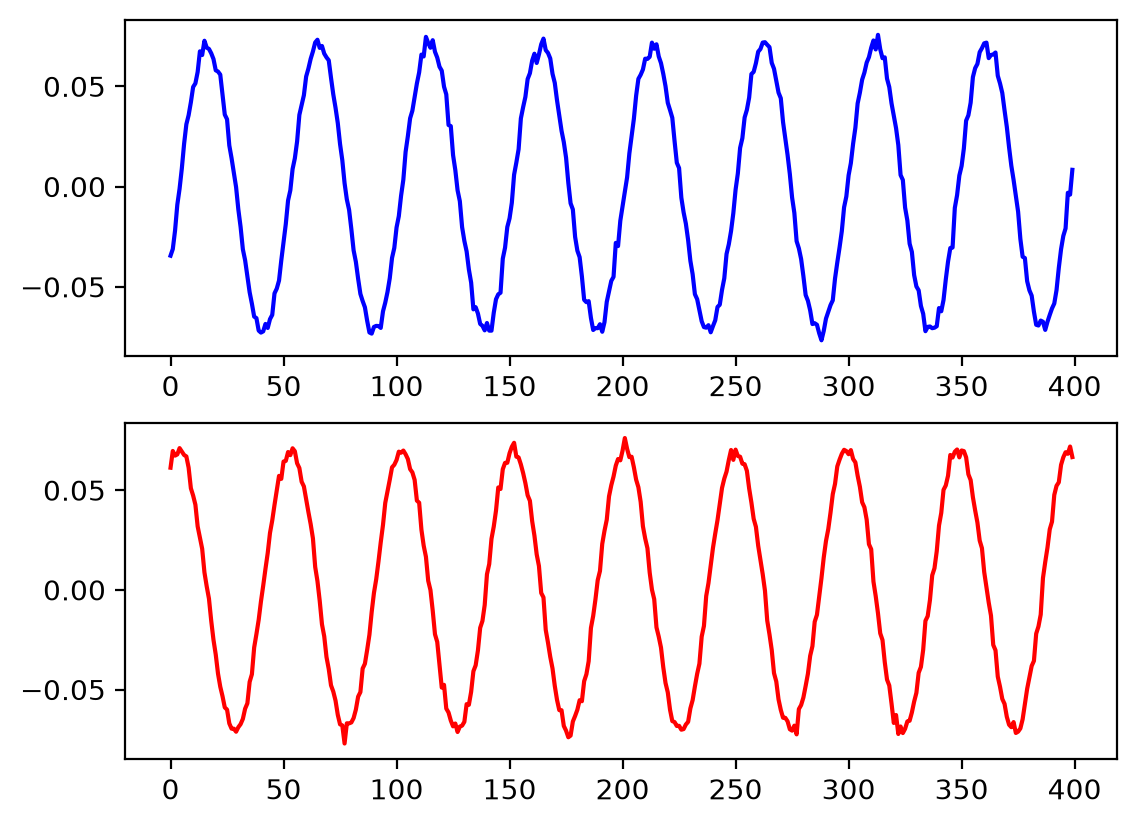

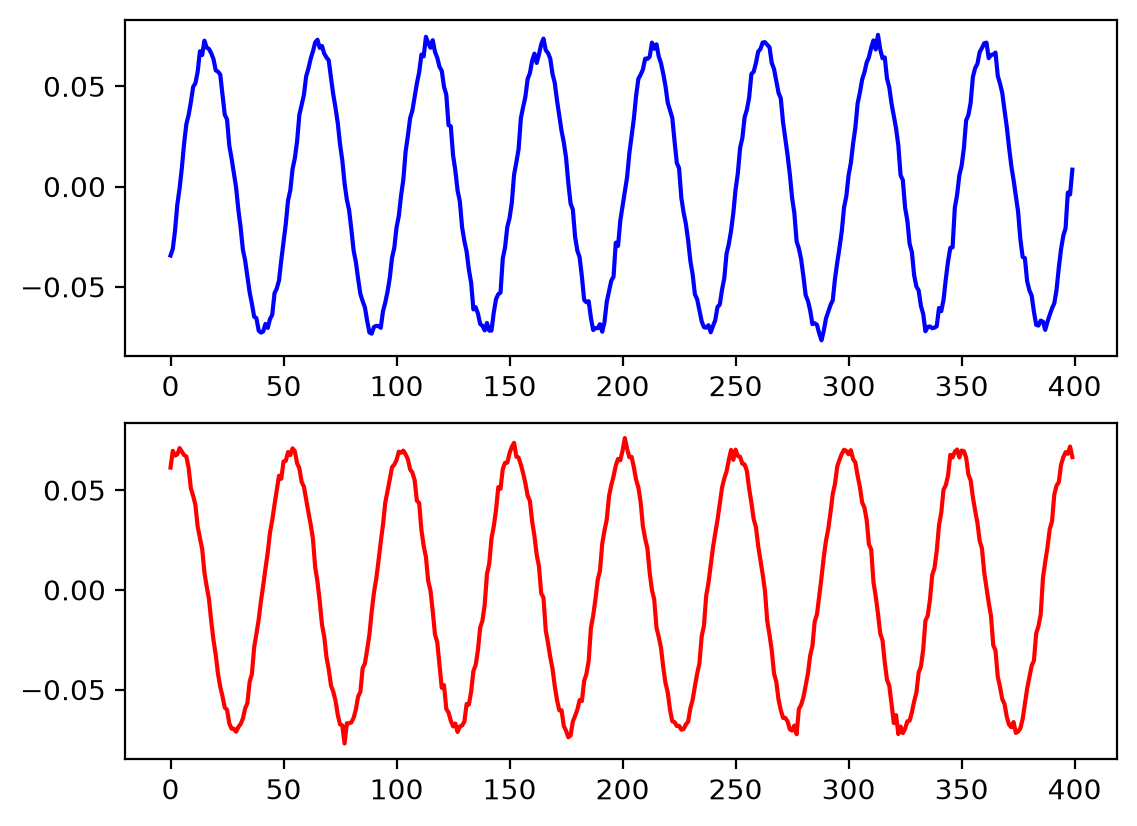

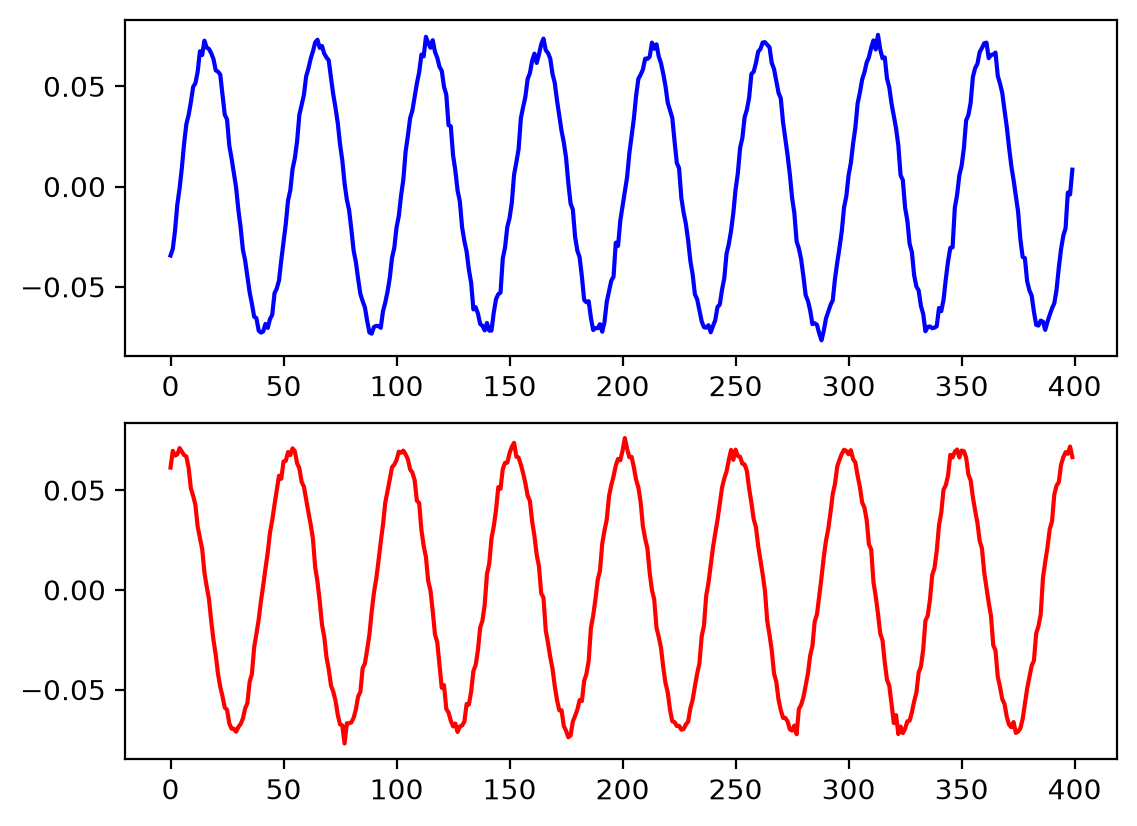

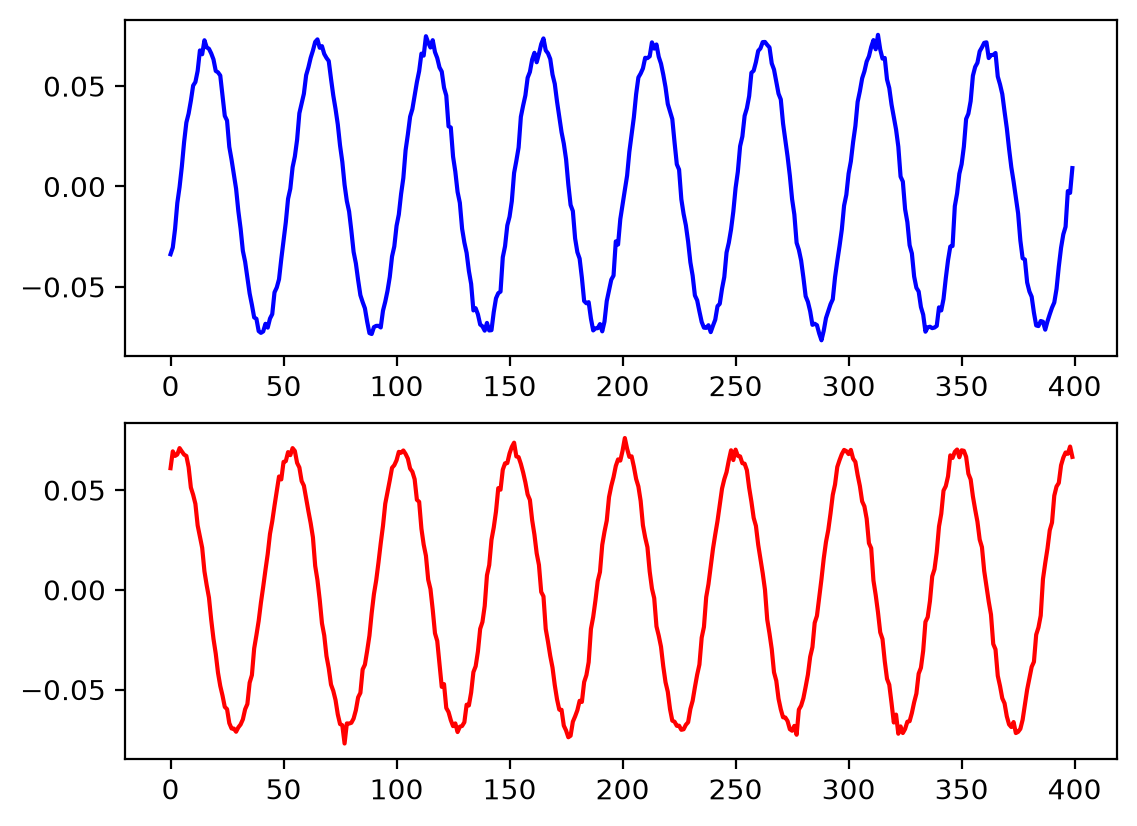

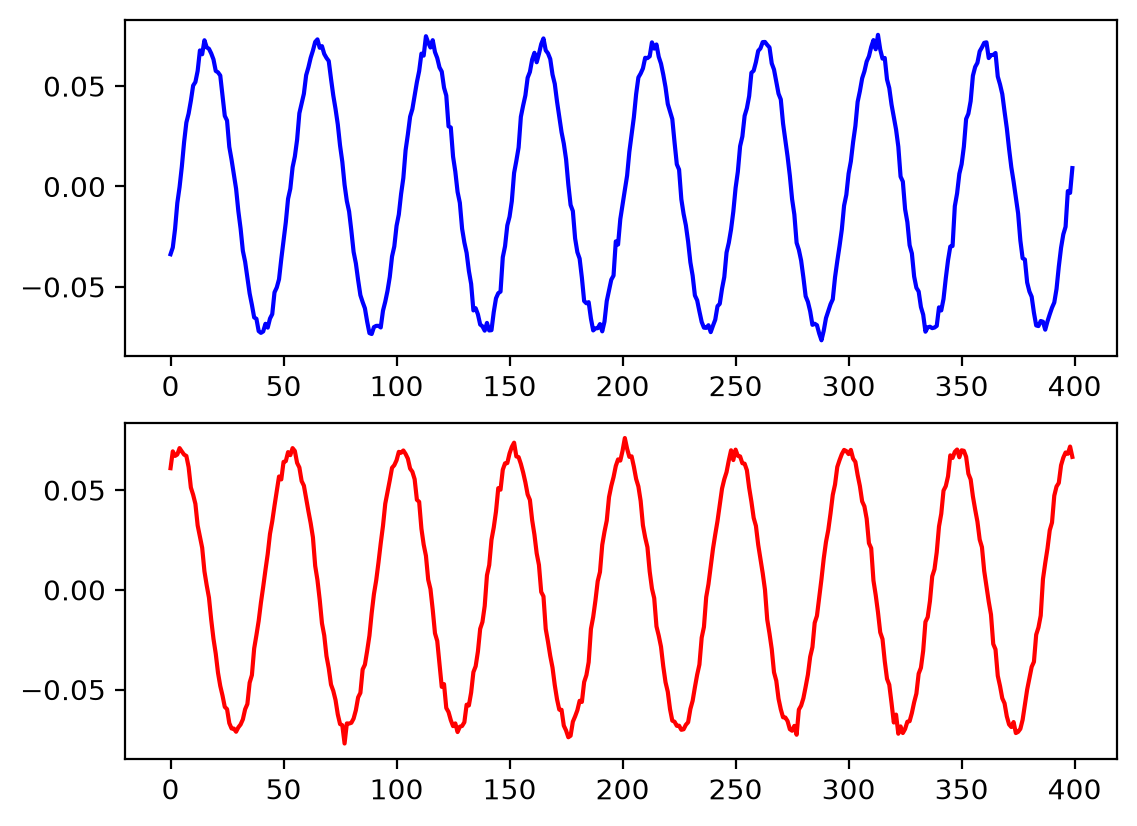

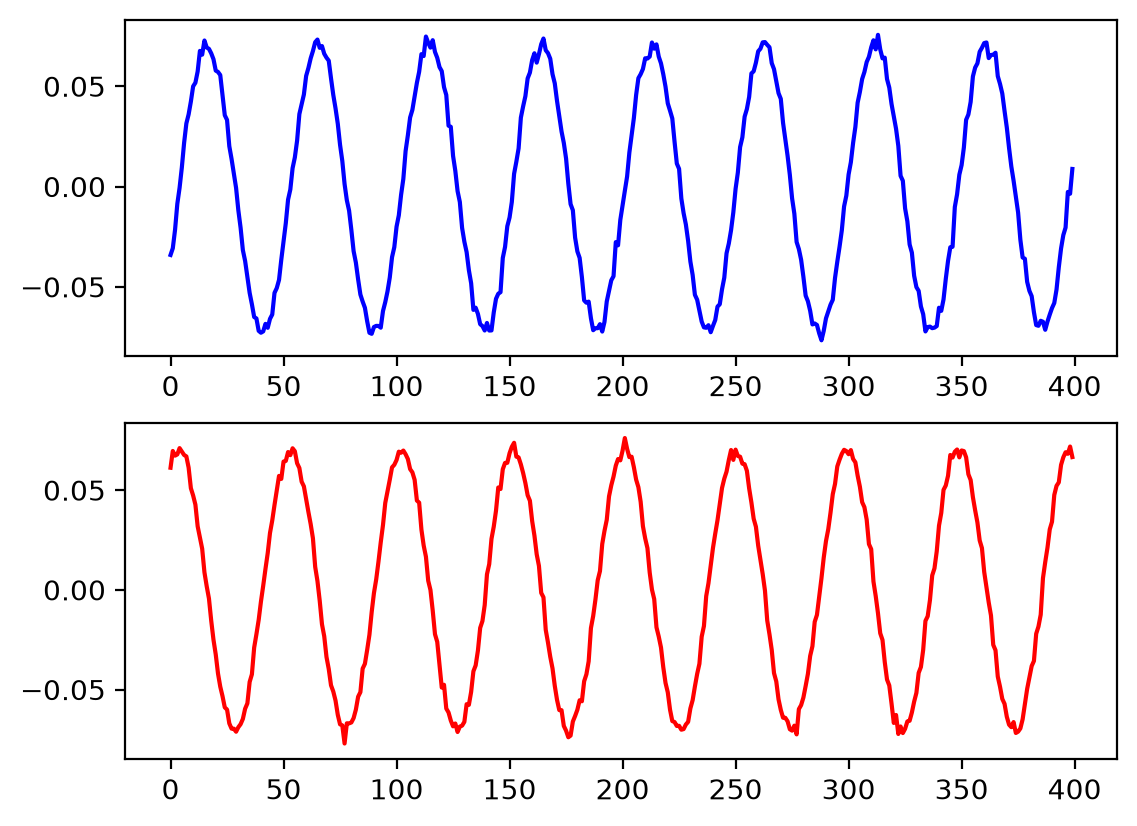

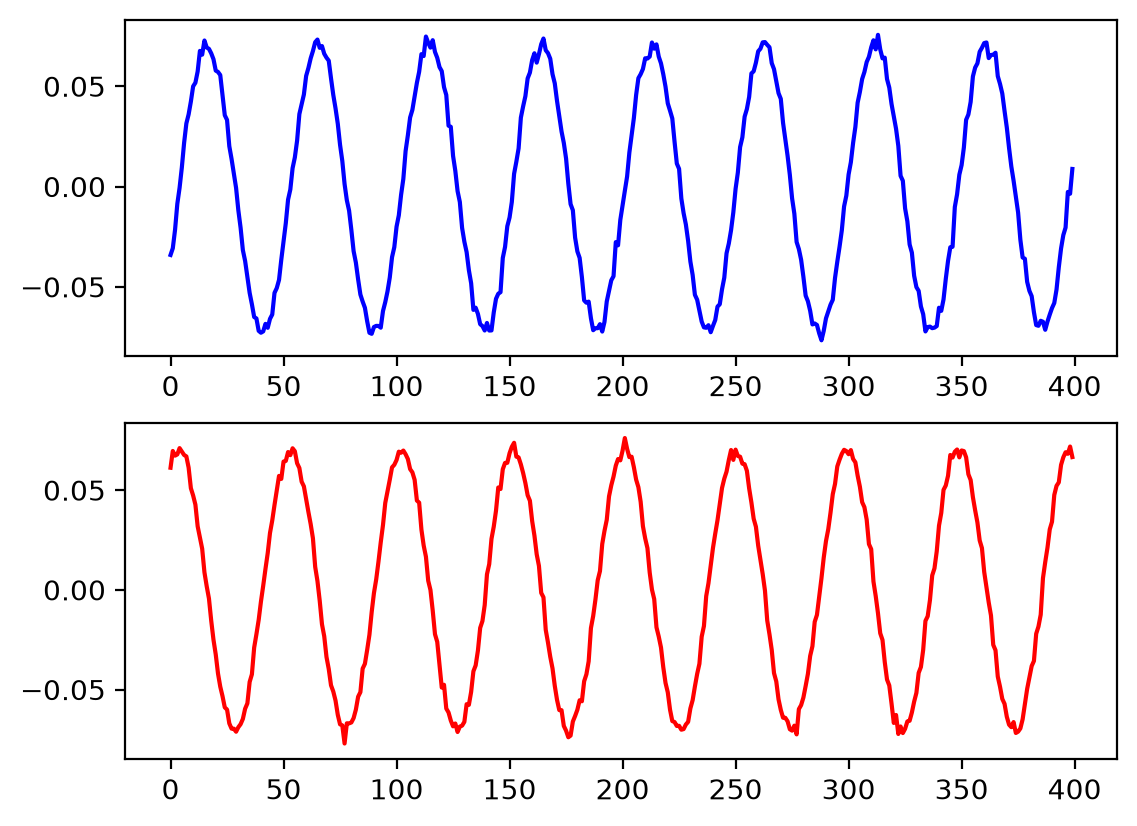

Done with training


In [16]:
n_iterations = 10000
codings = hidden
X_train = xmat.T
X_test = X_train

col = ['b','r','g','c','m','y','k']

sess = tf.InteractiveSession()
init.run()
    
for iteration in range(n_iterations):
    training_op.run(feed_dict={X: X_train})

    if iteration %1000 == 0:
        W_val = W.eval()
        plt.clf()
        for k in range(n_hidden):
            plt.subplot(n_hidden,1,k+1)
            plt.plot(W_val[:,k],col[k % len(col)])
        plt.show(False)
        plt.pause(0.001)

codings_val = codings.eval(feed_dict={X: X_test})

print("Done with training")

##### Question 1 (20 points)

What is an autoencoder? Please explain briefly. What would happen (ideally) if you pass a portion of signal x through the trained network?

An autoencoder is a neural network that learns to reconstruct its input after compressing it into a lower‑dimensional hidden representation, effectively learning a latent space that captures the main structure of the data rather than memorizing individual examples. In this assignment, each input is a short frame of the sin+noise signal, which is mapped into a 2‑dimensional code and then reconstructed back to the original 400‑sample frame; after training, passing a portion of signal x through the network should produce an output that closely matches the clean sinusoidal structure of the frame while attenuating random noise.


##### Question 2 (10 points)

Based on the observed shape of n_inputs and the definition of X_train, what exactly is being passed to the input layer of the network for a single forward pass? Be specific!

For each forward pass, the network input is one buffered frame of the signal: a 400‑sample time‑domain window from x. Since xmat has shape (400, number_of_frames) and we set X_train = xmat.T, each row of X_train is a single 400‑dimensional vector containing consecutive samples of the sin+noise signal, and this row is what feeds into the input layer placeholder X (with n_inputs = 400).

##### Question 3 (10 points)

What variable(s) are used to represent the network weights? How are these weights initialized prior to training?

The network weights are represented by the TensorFlow variable W, which is a matrix of shape (n_inputs, n_hidden) that maps input frames to the 2‑dimensional hidden layer and whose transpose maps the hidden layer back to the reconstructed output. These weights are initialized using tf.truncated_normal with a standard deviation of 0.1, and tf.global_variables_initializer() is called in the session to assign these random initial values before training.

##### Question  4 (10 points)

What is being minimized in the reconstruction loss? Why is this helpful?

The reconstruction loss minimizes the mean squared error between the output of the autoencoder and the original input frame, as given by tf.reduce_mean(tf.square(outputs - X)). By driving this error toward zero, training pushes the network to produce reconstructions that are as close as possible to the input, which in turn forces the 2‑dimensional hidden representation to capture the key structure of the signal (such as the sinusoidal pattern) while discarding less useful noise.

##### Question 5 (10 points)

What is an optimizer? What are 3 common optimizers? Which optimizer is used in this AE training? 

An optimizer is the procedure that adjusts the network’s parameters to minimize the chosen loss function, typically by using gradients of the loss with respect to the weights. Three common optimizers are stochastic gradient descent, RMSProp, and Adam. In this assignment, the autoencoder is trained using the Adam optimizer via tf.train.AdamOptimizer(learning_rate), with a learning rate of 0.01.

We can examine now the "codings", i.e. the hidden unit values and their distribution. The more signigicant codings should have smaller variances.

mean:  [-0.12929954  0.00138376]
variance [ 9.858413 10.094453]


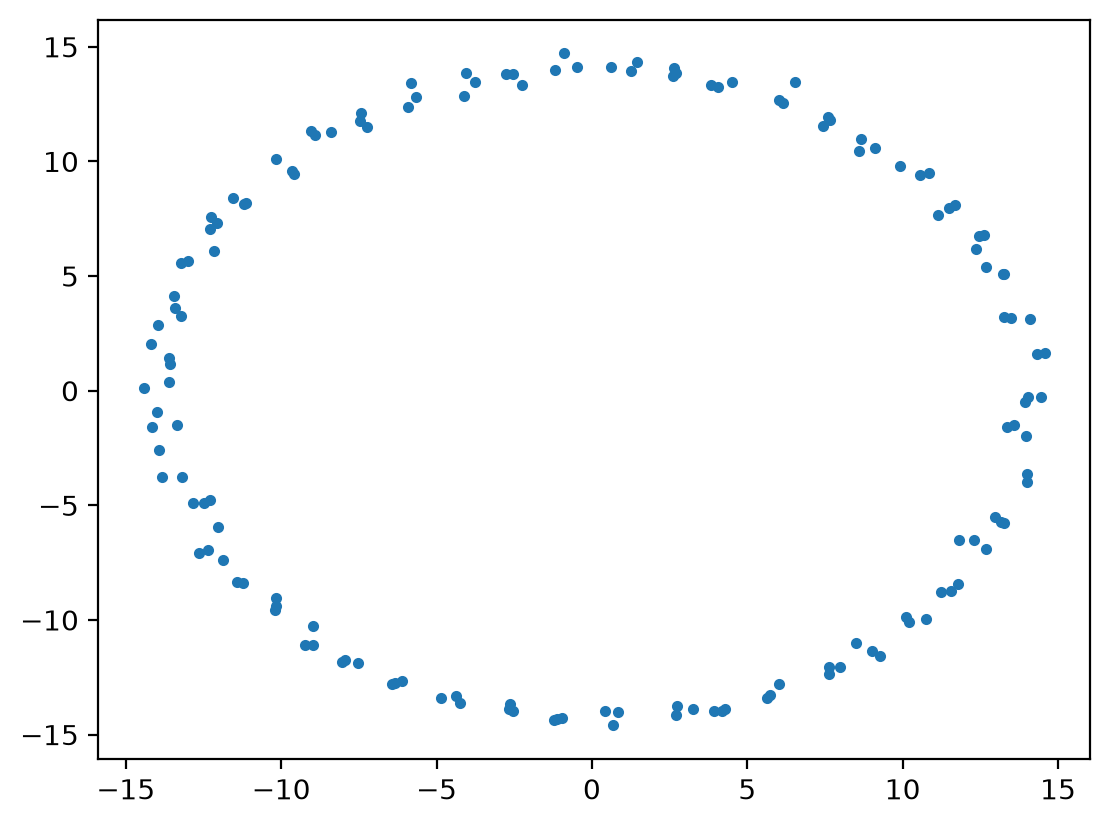

In [17]:
plt.plot(codings_val[:,0],codings_val[:,1],'.')
print ("mean: ", np.mean(codings_val,0))
print ("variance", np.std(codings_val,0))

#### Question 6 (10 points)

In what way does the autoencoder network function similarly to PCA?

This autoencoder behaves similarly to PCA because it is a purely linear model: the hidden representation is X multiplied by a weight matrix, and the reconstruction is that hidden representation multiplied by the transpose of the same matrix. When trained to minimize reconstruction mean squared error, the hidden layer learns a low‑dimensional linear subspace that best explains the variance in the data, analogous to PCA’s principal component subspace. In effect, the columns of W act like learned basis vectors similar to principal components, and the 2‑dimensional hidden codes are projections of each frame onto those directions.

##### PCA versus AE (30 points)

Using sklearn.decomposition.PCA (or another PCA implementation in Python), illustrate the ideas you discuss in Question 1 & Question 6. You should have two plots: one showing the output of the AE network on a single sample, and another showing the output of your PCA on the same sample. How many principal components do you use in your reconstruction to achieve similar performance to the AE network? 


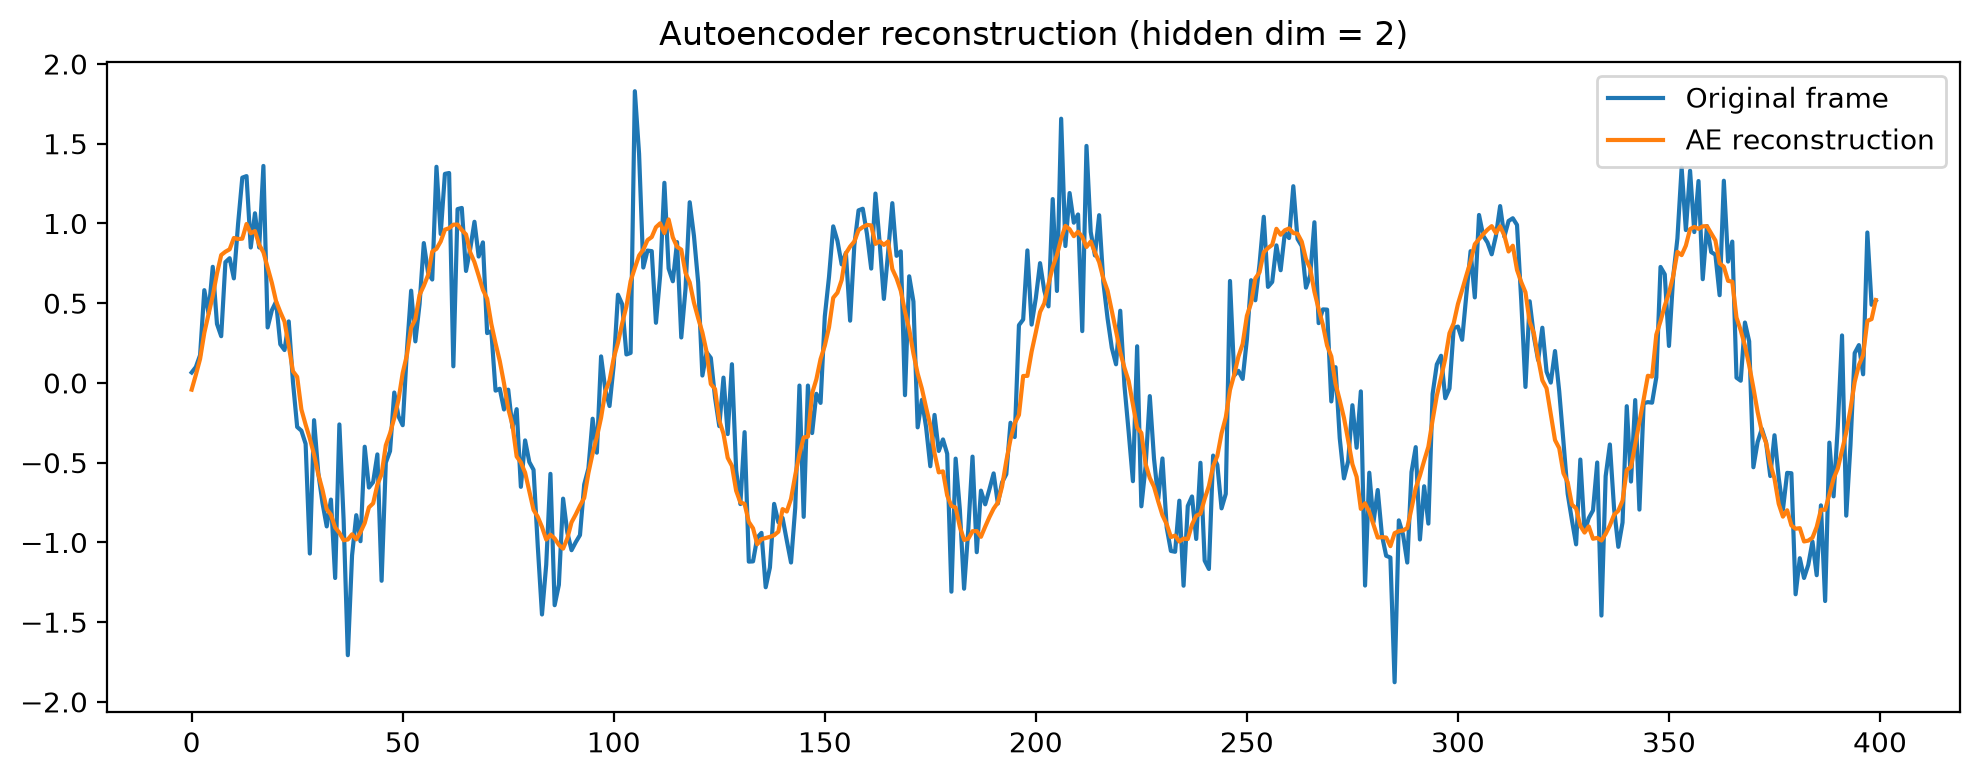

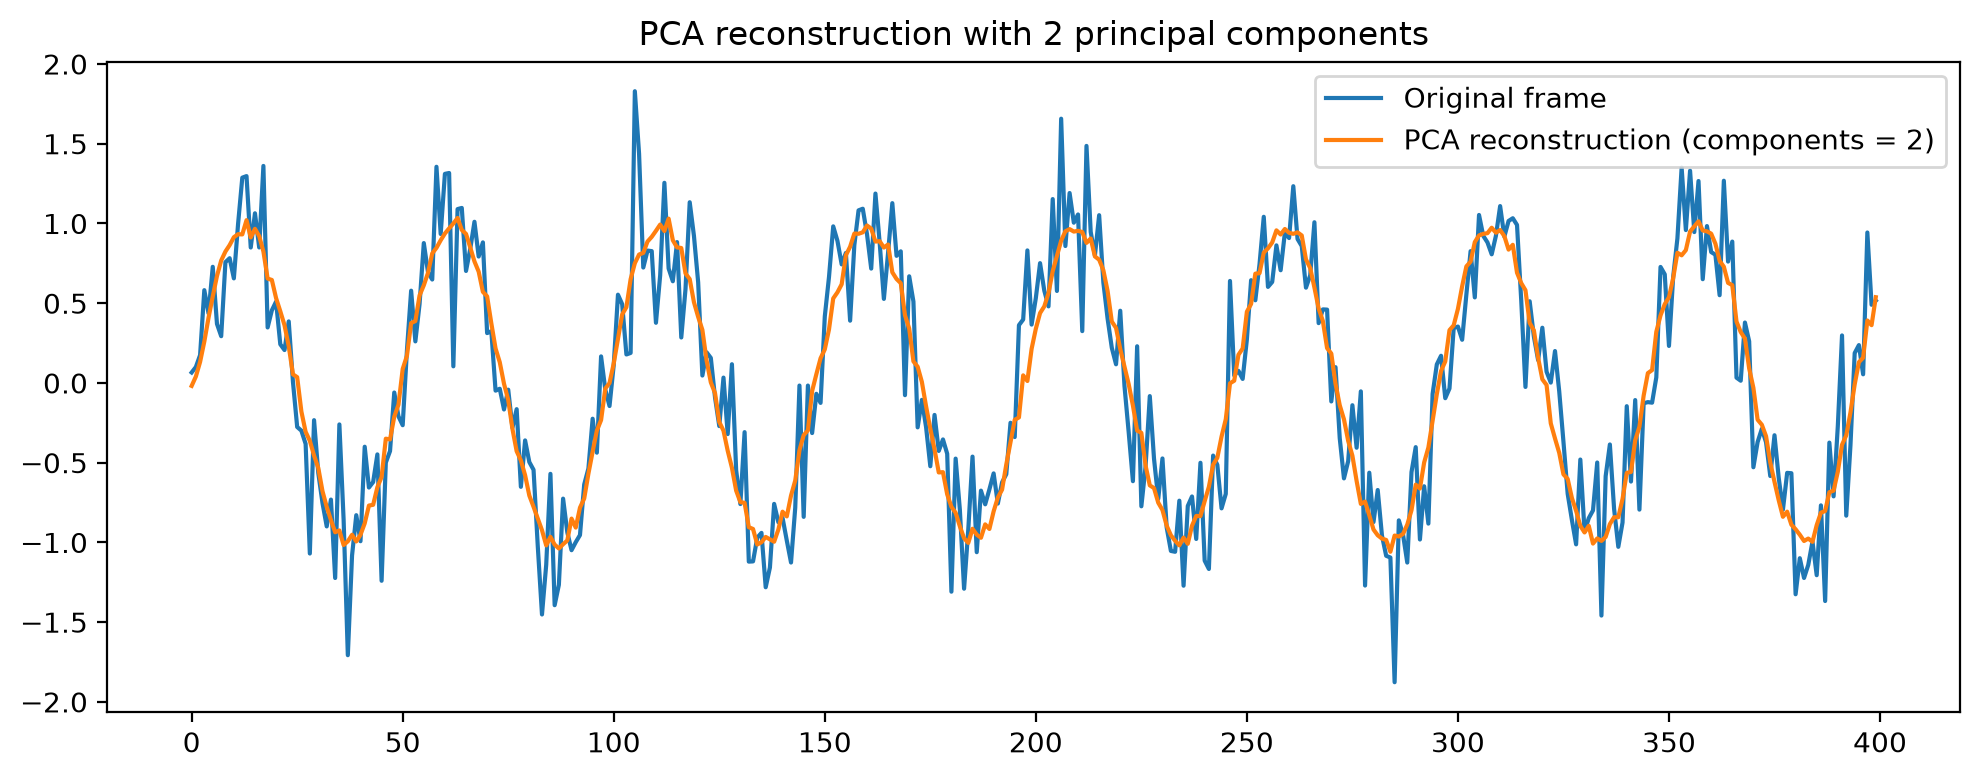

In [18]:
from sklearn.decomposition import PCA

# Choose a single sample index to visualize
sample_idx = 0
x_original = X_train[sample_idx]  # shape: (n_inputs,)

# Get AE reconstruction for that sample
# 'outputs' is the TensorFlow reconstruction node
ae_recon = outputs.eval(feed_dict={X: X_train[[sample_idx]]})[0]  # shape: (n_inputs,)

# PCA with same number of components as AE hidden units (n_hidden = 2)
n_components = n_hidden
pca = PCA(n_components=n_components)
pca.fit(X_train)

# Transform and inverse-transform the same sample
x_pca_code = pca.transform(X_train[[sample_idx]])  # shape: (1, n_components)
x_pca_recon = pca.inverse_transform(x_pca_code)[0]  # shape: (n_inputs,)

# Plot AE reconstruction vs original
plt.figure(figsize=(10, 4))
plt.plot(x_original, label='Original frame')
plt.plot(ae_recon, label='AE reconstruction')
plt.title(f'Autoencoder reconstruction (hidden dim = {n_hidden})')
plt.legend()
plt.tight_layout()
plt.show()

# Plot PCA reconstruction vs original
plt.figure(figsize=(10, 4))
plt.plot(x_original, label='Original frame')
plt.plot(x_pca_recon, label=f'PCA reconstruction (components = {n_components})')
plt.title(f'PCA reconstruction with {n_components} principal components')
plt.legend()
plt.tight_layout()
plt.show()

I used 2 principal components in PCA to mirror the 2‑dimensional bottleneck in the autoencoder. With 2 components, the PCA reconstruction visually matches the main sinusoidal structure of the frame about as well as the autoencoder reconstruction, indicating that both models are capturing a similar 2‑dimensional linear subspace of the data.

In [19]:
from sklearn.metrics import mean_squared_error

ae_mse = mean_squared_error(x_original, ae_recon)
pca_mse = mean_squared_error(x_original, x_pca_recon)

print("AE reconstruction MSE:", ae_mse)
print("PCA reconstruction MSE:", pca_mse)

AE reconstruction MSE: 0.08482834775072515
PCA reconstruction MSE: 0.08325889010768327


In [20]:
for n_components in [1, 2, 3]:
    pca = PCA(n_components=n_components)
    pca.fit(X_train)
    x_pca_recon = pca.inverse_transform(
        pca.transform(X_train[[sample_idx]])
    )[0]

    mse = mean_squared_error(x_original, x_pca_recon)
    print(f"Components = {n_components}, MSE = {mse}")

Components = 1, MSE = 0.5406245957837883
Components = 2, MSE = 0.08325889010768327
Components = 3, MSE = 0.08146139277596523


On this sample, the AE and PCA reconstructions have very similar mean squared errors, which confirms that both models are capturing comparable low‑dimensional structure in the sin+noise signal. Using 2 principal components provides a good trade‑off between compression and reconstruction fidelity, matching the 2‑dimensional bottleneck chosen for the autoencoder.
PCA-with-Linear-Autoencoder.pdf

Because both the linear AE and PCA are effectively learning a 2‑dimensional subspace that explains the variance of the buffered signal frames, their reconstructions show similar sinusoidal patterns and similar suppression of noise, even though PCA uses eigenvectors of the covariance matrix while the AE learns its basis vectors directly through gradient descent.


With 1 component, the reconstruction retains the basic sinusoidal shape but loses some fine detail, while 3 components give slightly lower error but more complexity. Choosing 2 components aligns with the AE bottleneck size and yields a reconstruction quality that is visually and numerically similar to the autoencoder.